# 02 Data Cleaning and Preprocessing

This notebook continues from the data collection and multi-source merge pipeline.
Input file:
```text
data/processed/final_merged_all.csv
```
Output files:
```text
data/processed/cleaned_dataset.csv
data/processed/cleaning_report.csv
```
Main cleaning steps:
1. Load the merged dataset.
2. Check data types, missing values, duplicates and time continuity.
3. Remove non-modeling columns.
4. Convert all numeric columns correctly.
5. Handle missing values in ARPA and ERA5 variables.
6. Add time-based and wind-direction features.
7. Check obvious invalid values and outlier ranges.
8. Save the cleaned dataset.

In [6]:
# Cell 1 — Import libraries and set project paths

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The notebook is expected to be inside notebooks/
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

INPUT_FILE = PROCESSED_DIR / "final_merged_all.csv"
OUTPUT_FILE = PROCESSED_DIR / "cleaned_dataset.csv"
REPORT_FILE = PROCESSED_DIR / "cleaning_report.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Input file:", INPUT_FILE)
print("Output file:", OUTPUT_FILE)


Project root: D:\eo\GeoProject_oo
Input file: D:\eo\GeoProject_oo\data\processed\final_merged_all.csv
Output file: D:\eo\GeoProject_oo\data\processed\cleaned_dataset.csv


In [7]:
# Cell 2 — Load merged dataset

df_raw = pd.read_csv(INPUT_FILE)

print("Raw dataset shape:", df_raw.shape)
df_raw.head()


Raw dataset shape: (220, 34)


,time,R_roi,G_roi,B_roi,S_mean,B_R_ratio,contrast,image_path,PM25,Unit,...,T_850,U_500,U_850,V_500,V_850,temperature_mean,wind_direction_mean,relative_humidity_mean,wind_speed_mean,wind_gust_max
0,2026-03-01 03:00:00,86.929729,103.464931,122.421467,0.289659,1.408281,19.216036,data\raw\images\20260301-0400.jpg,30.829412,ug.m-3,...,275.30075,9.322769,-0.278305,9.539322,0.779373,11.6,73.0,76.2,0.7,2.2
1,2026-03-01 04:00:00,86.585585,103.941114,123.104967,0.295599,1.421772,14.566550,data\raw\images\20260301-0500.jpg,33.409030,ug.m-3,...,275.04828,9.351929,-0.919876,9.568161,0.440033,11.3,84.0,81.4,1.3,3.1
2,2026-03-01 05:00:00,88.296336,103.318508,121.759842,0.273444,1.378991,13.688991,data\raw\images\20260301-0600.jpg,45.526115,ug.m-3,...,274.86044,9.384903,-1.381363,9.571930,0.111649,10.9,74.0,86.8,1.1,2.6
3,2026-03-01 06:00:00,97.633802,127.312248,157.806914,0.381747,1.616314,17.681540,data\raw\images\20260301-0700.jpg,45.983295,ug.m-3,...,274.77585,8.750961,-1.646408,9.686996,-0.082336,10.7,72.0,89.3,1.6,3.3
4,2026-03-01 07:00:00,112.164859,144.062795,172.776857,0.352871,1.540383,21.163309,data\raw\images\20260301-0800.jpg,47.228165,ug.m-3,...,274.84160,8.000458,-1.764099,10.094360,0.228470,10.3,87.0,93.2,2.2,4.2


In [8]:
# Cell 3 — Basic dataset inspection

print("Dataset info:")
print(df_raw.info())

print("\nDuplicated rows:", df_raw.duplicated().sum())

missing_summary = (
    pd.DataFrame({
        "missing_count": df_raw.isna().sum(),
        "missing_ratio_percent": df_raw.isna().mean() * 100,
    })
    .sort_values("missing_ratio_percent", ascending=False)
)

missing_summary.head(15)


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   time                    220 non-null    object 
 1   R_roi                   220 non-null    float64
 2   G_roi                   220 non-null    float64
 3   B_roi                   220 non-null    float64
 4   S_mean                  220 non-null    float64
 5   B_R_ratio               220 non-null    float64
 6   contrast                220 non-null    float64
 7   image_path              220 non-null    object 
 8   PM25                    220 non-null    float64
 9   Unit                    220 non-null    object 
 10  T2M                     220 non-null    float64
 11  D2M                     220 non-null    float64
 12  RH                      220 non-null    float64
 13  U10                     220 non-null    float64
 14  V10                     220 

,missing_count,missing_ratio_percent
wind_speed_mean,49,22.272727
CBH,25,11.363636
wind_direction_mean,2,0.909091
time,0,0.000000
R_roi,0,0.000000
G_roi,0,0.000000
contrast,0,0.000000
B_roi,0,0.000000
S_mean,0,0.000000
B_R_ratio,0,0.000000


In [9]:
# Cell 4 — Create working copy and convert time column

df = df_raw.copy()

df["time"] = pd.to_datetime(df["time"], errors="coerce")

print("Invalid time values:", df["time"].isna().sum())

df = df.sort_values("time").reset_index(drop=True)

print("Time range:", df["time"].min(), "to", df["time"].max())
print("Number of rows:", len(df))

df.head()


Invalid time values: 0
Time range: 2026-03-01 03:00:00 to 2026-03-12 22:00:00
Number of rows: 220


,time,R_roi,G_roi,B_roi,S_mean,B_R_ratio,contrast,image_path,PM25,Unit,...,T_850,U_500,U_850,V_500,V_850,temperature_mean,wind_direction_mean,relative_humidity_mean,wind_speed_mean,wind_gust_max
0,2026-03-01 03:00:00,86.929729,103.464931,122.421467,0.289659,1.408281,19.216036,data\raw\images\20260301-0400.jpg,30.829412,ug.m-3,...,275.30075,9.322769,-0.278305,9.539322,0.779373,11.6,73.0,76.2,0.7,2.2
1,2026-03-01 04:00:00,86.585585,103.941114,123.104967,0.295599,1.421772,14.566550,data\raw\images\20260301-0500.jpg,33.409030,ug.m-3,...,275.04828,9.351929,-0.919876,9.568161,0.440033,11.3,84.0,81.4,1.3,3.1
2,2026-03-01 05:00:00,88.296336,103.318508,121.759842,0.273444,1.378991,13.688991,data\raw\images\20260301-0600.jpg,45.526115,ug.m-3,...,274.86044,9.384903,-1.381363,9.571930,0.111649,10.9,74.0,86.8,1.1,2.6
3,2026-03-01 06:00:00,97.633802,127.312248,157.806914,0.381747,1.616314,17.681540,data\raw\images\20260301-0700.jpg,45.983295,ug.m-3,...,274.77585,8.750961,-1.646408,9.686996,-0.082336,10.7,72.0,89.3,1.6,3.3
4,2026-03-01 07:00:00,112.164859,144.062795,172.776857,0.352871,1.540383,21.163309,data\raw\images\20260301-0800.jpg,47.228165,ug.m-3,...,274.84160,8.000458,-1.764099,10.094360,0.228470,10.3,87.0,93.2,2.2,4.2


In [10]:
# Cell 5 — Check time continuity

# Expected data frequency is hourly because image, PM2.5, ERA5 and ARPA data are aligned by hour.
time_diff = df["time"].diff()

print("Time step counts:")
print(time_diff.value_counts().head(10))

expected_freq = pd.Timedelta(hours=1)
missing_time_steps = time_diff[time_diff > expected_freq]

print("\nNumber of gaps larger than 1 hour:", len(missing_time_steps))

if len(missing_time_steps) > 0:
    gap_report = df.loc[missing_time_steps.index, ["time"]].copy()
    gap_report["previous_time"] = df.loc[missing_time_steps.index - 1, "time"].values
    gap_report["gap"] = gap_report["time"] - gap_report["previous_time"]
    display(gap_report)


Time step counts:
time
0 days 01:00:00    209
0 days 05:00:00      9
1 days 05:00:00      1
Name: count, dtype: int64

Number of gaps larger than 1 hour: 10


,time,previous_time,gap
20,2026-03-03 03:00:00,2026-03-01 22:00:00,1 days 05:00:00
40,2026-03-04 03:00:00,2026-03-03 22:00:00,0 days 05:00:00
60,2026-03-05 03:00:00,2026-03-04 22:00:00,0 days 05:00:00
80,2026-03-06 03:00:00,2026-03-05 22:00:00,0 days 05:00:00
100,2026-03-07 03:00:00,2026-03-06 22:00:00,0 days 05:00:00
120,2026-03-08 03:00:00,2026-03-07 22:00:00,0 days 05:00:00
140,2026-03-09 03:00:00,2026-03-08 22:00:00,0 days 05:00:00
160,2026-03-10 03:00:00,2026-03-09 22:00:00,0 days 05:00:00
180,2026-03-11 03:00:00,2026-03-10 22:00:00,0 days 05:00:00
200,2026-03-12 03:00:00,2026-03-11 22:00:00,0 days 05:00:00


In [11]:
# Cell 6 — Remove columns not used for numerical modeling

# image_path is useful for tracing images, but not useful as a numerical feature.
# Unit is constant for PM2.5 and therefore not useful for modeling.
columns_to_drop = ["image_path", "Unit"]

existing_drop_columns = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_drop_columns)

print("Dropped columns:", existing_drop_columns)
print("Shape after dropping columns:", df.shape)
df.head()


Dropped columns: ['image_path', 'Unit']
Shape after dropping columns: (220, 32)


,time,R_roi,G_roi,B_roi,S_mean,B_R_ratio,contrast,PM25,T2M,D2M,...,T_850,U_500,U_850,V_500,V_850,temperature_mean,wind_direction_mean,relative_humidity_mean,wind_speed_mean,wind_gust_max
0,2026-03-01 03:00:00,86.929729,103.464931,122.421467,0.289659,1.408281,19.216036,30.829412,282.71730,281.67267,...,275.30075,9.322769,-0.278305,9.539322,0.779373,11.6,73.0,76.2,0.7,2.2
1,2026-03-01 04:00:00,86.585585,103.941114,123.104967,0.295599,1.421772,14.566550,33.409030,282.71070,281.80220,...,275.04828,9.351929,-0.919876,9.568161,0.440033,11.3,84.0,81.4,1.3,3.1
2,2026-03-01 05:00:00,88.296336,103.318508,121.759842,0.273444,1.378991,13.688991,45.526115,282.70300,281.83790,...,274.86044,9.384903,-1.381363,9.571930,0.111649,10.9,74.0,86.8,1.1,2.6
3,2026-03-01 06:00:00,97.633802,127.312248,157.806914,0.381747,1.616314,17.681540,45.983295,282.62634,281.76056,...,274.77585,8.750961,-1.646408,9.686996,-0.082336,10.7,72.0,89.3,1.6,3.3
4,2026-03-01 07:00:00,112.164859,144.062795,172.776857,0.352871,1.540383,21.163309,47.228165,282.59164,281.74936,...,274.84160,8.000458,-1.764099,10.094360,0.228470,10.3,87.0,93.2,2.2,4.2


In [12]:
# Cell 7 — Convert feature columns to numeric where possible

# Some ARPA columns may be loaded as object because of missing values such as <NA>.
# Keep only the time column as datetime; all other columns should be numeric.
for col in df.columns:
    if col != "time":
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)


time                      datetime64[ns]
R_roi                            float64
G_roi                            float64
B_roi                            float64
S_mean                           float64
B_R_ratio                        float64
contrast                         float64
PM25                             float64
T2M                              float64
D2M                              float64
RH                               float64
U10                              float64
V10                              float64
SP                               float64
TP                               float64
BLH                              float64
TCC                              float64
CBH                              float64
WS10                             float64
GP_500                           float64
GP_850                           float64
T_500                            float64
T_850                            float64
U_500                            float64
U_850           

In [13]:
# Cell 8 — Missing values before cleaning

missing_before = (
    pd.DataFrame({
        "missing_count_before": df.isna().sum(),
        "missing_ratio_before_percent": df.isna().mean() * 100,
    })
    .sort_values("missing_ratio_before_percent", ascending=False)
)

missing_before[missing_before["missing_count_before"] > 0]


,missing_count_before,missing_ratio_before_percent
wind_speed_mean,49,22.272727
CBH,25,11.363636
wind_direction_mean,2,0.909091


## Missing-value strategy

The current missing values mainly come from two sources:

- `wind_speed_mean` and `wind_direction_mean`: ARPA ground station observations.
- `CBH`: ERA5 cloud base height. This variable can be missing when cloud base is not defined.

For this stage, the dataset is hourly and ordered in time, so the cleaning uses time-aware interpolation instead of mean imputation.


In [14]:
# Cell 9 — Handle missing values in continuous variables

# Linear interpolation is suitable for continuous hourly variables.
linear_interpolation_columns = [
    "wind_speed_mean",
    "CBH",
]

for col in linear_interpolation_columns:
    if col in df.columns:
        df[col] = df[col].interpolate(method="linear", limit_direction="both")

print("Missing values after linear interpolation:")
print(df[linear_interpolation_columns].isna().sum())


Missing values after linear interpolation:
wind_speed_mean    0
CBH                0
dtype: int64


In [16]:
# Cell 10 — Handle wind direction carefully

# Wind direction is circular data.
# For the very small number of missing values, nearest interpolation is safer than mean imputation.
if "wind_direction_mean" in df.columns:
    df["wind_direction_mean"] = (
        df["wind_direction_mean"]
        .ffill()
        .bfill()
)

print("Missing wind_direction_mean values:", df["wind_direction_mean"].isna().sum())


Missing wind_direction_mean values: 0


In [17]:
# Cell 11 — Final missing-value check

missing_after = (
    pd.DataFrame({
        "missing_count_after": df.isna().sum(),
        "missing_ratio_after_percent": df.isna().mean() * 100,
    })
    .sort_values("missing_ratio_after_percent", ascending=False)
)

missing_after[missing_after["missing_count_after"] > 0]


,missing_count_after,missing_ratio_after_percent


In [18]:
# Cell 12 — If any unexpected missing values remain, fill conservatively

# This is a safety step. It should normally do nothing after the interpolation above.
remaining_missing = df.isna().sum().sum()
print("Remaining missing values before safety fill:", remaining_missing)

if remaining_missing > 0:
    df = df.ffill().bfill()

print("Remaining missing values after safety fill:", df.isna().sum().sum())


Remaining missing values before safety fill: 0
Remaining missing values after safety fill: 0


In [19]:
# Cell 13 — Check invalid physical values

# These checks do not automatically delete rows.
# They only help identify suspicious values before modeling.
checks = {}

if "PM25" in df.columns:
    checks["PM25_negative"] = int((df["PM25"] < 0).sum())

if "RH" in df.columns:
    checks["ERA5_RH_outside_0_100"] = int(((df["RH"] < 0) | (df["RH"] > 100)).sum())

if "relative_humidity_mean" in df.columns:
    checks["ARPA_RH_outside_0_100"] = int(((df["relative_humidity_mean"] < 0) | (df["relative_humidity_mean"] > 100)).sum())

if "TCC" in df.columns:
    checks["TCC_outside_0_1"] = int(((df["TCC"] < 0) | (df["TCC"] > 1)).sum())

if "TP" in df.columns:
    checks["TP_negative"] = int((df["TP"] < 0).sum())

if "wind_speed_mean" in df.columns:
    checks["wind_speed_mean_negative"] = int((df["wind_speed_mean"] < 0).sum())

if "WS10" in df.columns:
    checks["WS10_negative"] = int((df["WS10"] < 0).sum())

pd.DataFrame.from_dict(checks, orient="index", columns=["count"])


,count
PM25_negative,0
ERA5_RH_outside_0_100,0
ARPA_RH_outside_0_100,0
TCC_outside_0_1,0
TP_negative,0
wind_speed_mean_negative,0
WS10_negative,0


In [20]:
# Cell 14 — Remove clearly invalid rows if they exist

initial_rows = len(df)

if "PM25" in df.columns:
    df = df[df["PM25"] >= 0]

if "RH" in df.columns:
    df = df[(df["RH"] >= 0) & (df["RH"] <= 100)]

if "relative_humidity_mean" in df.columns:
    df = df[(df["relative_humidity_mean"] >= 0) & (df["relative_humidity_mean"] <= 100)]

if "TCC" in df.columns:
    df = df[(df["TCC"] >= 0) & (df["TCC"] <= 1)]

if "TP" in df.columns:
    df = df[df["TP"] >= 0]

if "wind_speed_mean" in df.columns:
    df = df[df["wind_speed_mean"] >= 0]

if "WS10" in df.columns:
    df = df[df["WS10"] >= 0]

df = df.reset_index(drop=True)

print("Rows before invalid-value filtering:", initial_rows)
print("Rows after invalid-value filtering:", len(df))
print("Rows removed:", initial_rows - len(df))


Rows before invalid-value filtering: 220
Rows after invalid-value filtering: 220
Rows removed: 0


In [21]:
# Cell 15 — Outlier overview with IQR flags

# At this stage, outliers are flagged but not removed automatically.
# PM2.5 peaks and weather extremes may be real and useful for modeling.
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

outlier_rows = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df[col] < lower) | (df[col] > upper)).sum())
    outlier_rows.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "iqr_outlier_count": count,
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("iqr_outlier_count", ascending=False)
outlier_summary.head(15)


,column,lower_bound,upper_bound,iqr_outlier_count
13,TP,-0.000015,0.000025,46
16,CBH,-521.634362,2271.784937,17
29,wind_speed_mean,-0.300000,2.100000,11
4,B_R_ratio,1.293693,1.683265,10
3,S_mean,0.250837,0.422726,10
6,PM25,20.511961,65.477551,9
12,SP,100432.922500,101416.514500,4
19,GP_850,14714.111000,15563.835000,2
25,V_850,-4.287121,6.154255,2
30,wind_gust_max,-1.100000,6.100000,2


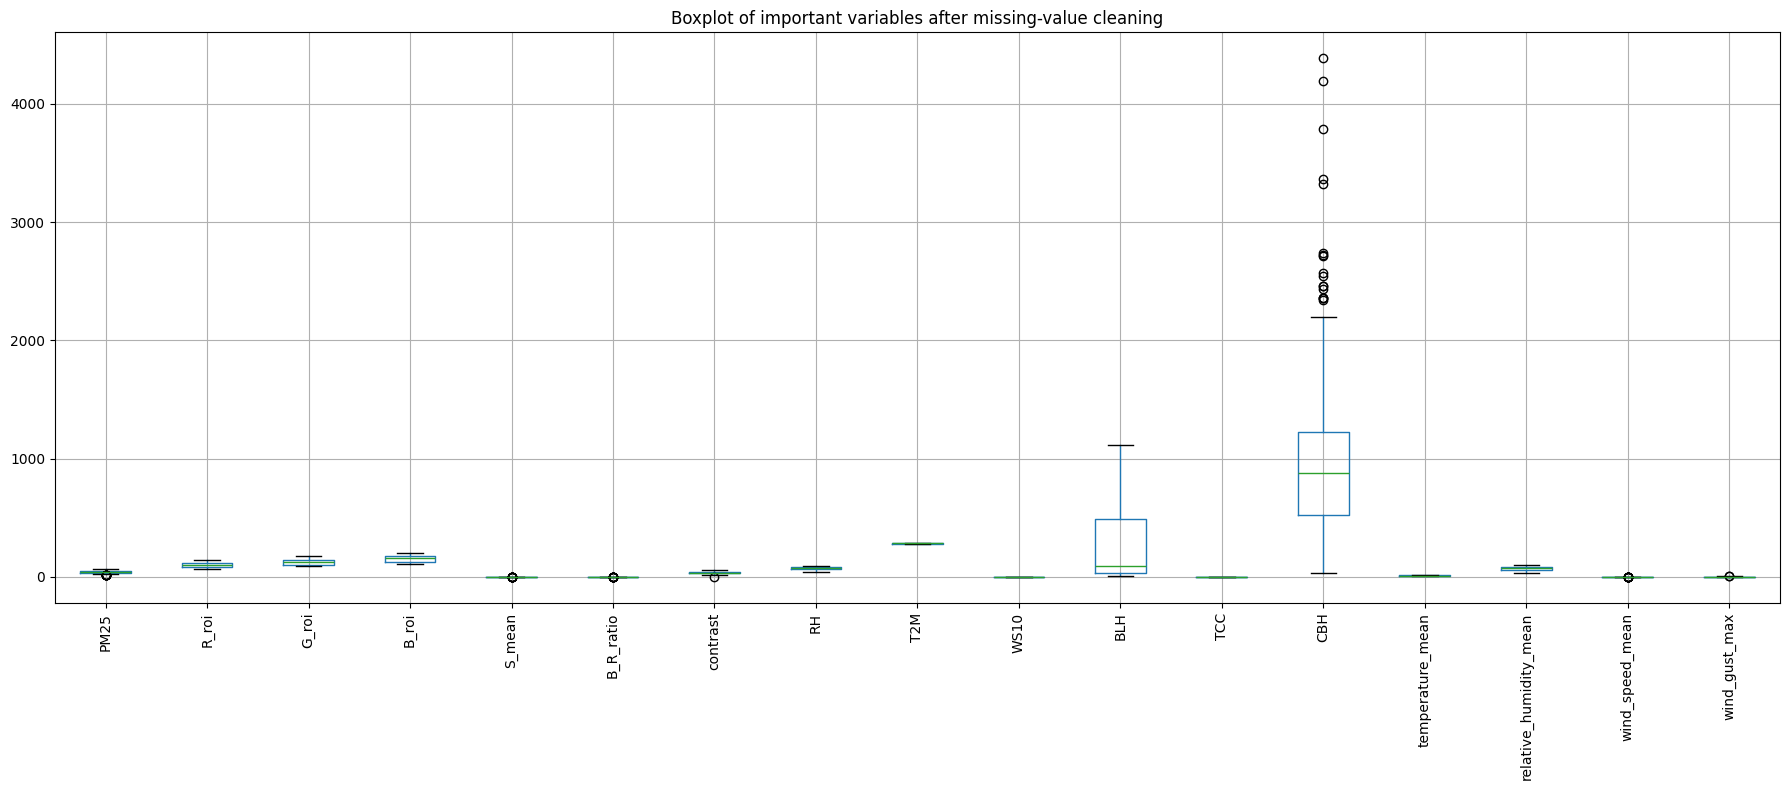

In [22]:
# Cell 16 — Boxplot for important variables

important_columns = [
    "PM25",
    "R_roi", "G_roi", "B_roi", "S_mean", "B_R_ratio", "contrast",
    "RH", "T2M", "WS10", "BLH", "TCC", "CBH",
    "temperature_mean", "relative_humidity_mean", "wind_speed_mean", "wind_gust_max",
]

plot_columns = [col for col in important_columns if col in df.columns]

plt.figure(figsize=(18, 8))
df[plot_columns].boxplot(rot=90)
plt.title("Boxplot of important variables after missing-value cleaning")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_cleaning_boxplot_important_variables.png", dpi=150)
plt.show()


In [23]:
# Cell 17 — Add time-based features

# These features are useful because air pollution and illumination have daily cycles.
df["hour"] = df["time"].dt.hour
df["day"] = df["time"].dt.day
df["weekday"] = df["time"].dt.weekday
df["month"] = df["time"].dt.month

# Cyclical encoding for hour.
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# A simple daylight flag for preliminary analysis.
# This is not a precise astronomical sunrise/sunset calculation, but is useful for the first model iteration.
df["is_daytime"] = ((df["hour"] >= 6) & (df["hour"] <= 18)).astype(int)

df[["time", "hour", "weekday", "hour_sin", "hour_cos", "is_daytime"]].head()


,time,hour,weekday,hour_sin,hour_cos,is_daytime
0,2026-03-01 03:00:00,3,6,0.707107,7.071068e-01,0
1,2026-03-01 04:00:00,4,6,0.866025,5.000000e-01,0
2,2026-03-01 05:00:00,5,6,0.965926,2.588190e-01,0
3,2026-03-01 06:00:00,6,6,1.000000,6.123234e-17,1
4,2026-03-01 07:00:00,7,6,0.965926,-2.588190e-01,1


In [24]:
# Cell 18 — Convert wind direction to circular features

if "wind_direction_mean" in df.columns:
    df["wind_dir_sin"] = np.sin(np.radians(df["wind_direction_mean"]))
    df["wind_dir_cos"] = np.cos(np.radians(df["wind_direction_mean"]))

    # Keep the original angle for traceability, but the sin/cos features should be preferred in modeling.
    print(df[["wind_direction_mean", "wind_dir_sin", "wind_dir_cos"]].head())


   wind_direction_mean  wind_dir_sin  wind_dir_cos
0                 73.0      0.956305      0.292372
1                 84.0      0.994522      0.104528
2                 74.0      0.961262      0.275637
3                 72.0      0.951057      0.309017
4                 87.0      0.998630      0.052336


In [25]:
# Cell 19 — Quick correlation with PM2.5

if "PM25" in df.columns:
    corr_with_pm25 = (
        df.select_dtypes(include=np.number)
        .corr()["PM25"]
        .sort_values(ascending=False)
    )

    display(corr_with_pm25.head(15))
    display(corr_with_pm25.tail(15))


PM25                      1.000000
hour_sin                  0.477810
R_roi                     0.461179
G_roi                     0.421139
B_roi                     0.419280
TCC                       0.403715
relative_humidity_mean    0.370075
U10                       0.353277
wind_dir_cos              0.180907
TP                        0.180183
V_850                     0.166620
U_850                     0.165966
BLH                       0.161765
is_daytime                0.140267
V_500                     0.138077
Name: PM25, dtype: float64

contrast           -0.058129
weekday            -0.104922
V10                -0.130347
D2M                -0.153143
T2M                -0.166222
wind_dir_sin       -0.167639
hour_cos           -0.248608
WS10               -0.261002
B_R_ratio          -0.319287
S_mean             -0.339797
T_850              -0.342489
temperature_mean   -0.382762
CBH                -0.391022
hour               -0.418390
month                    NaN
Name: PM25, dtype: float64

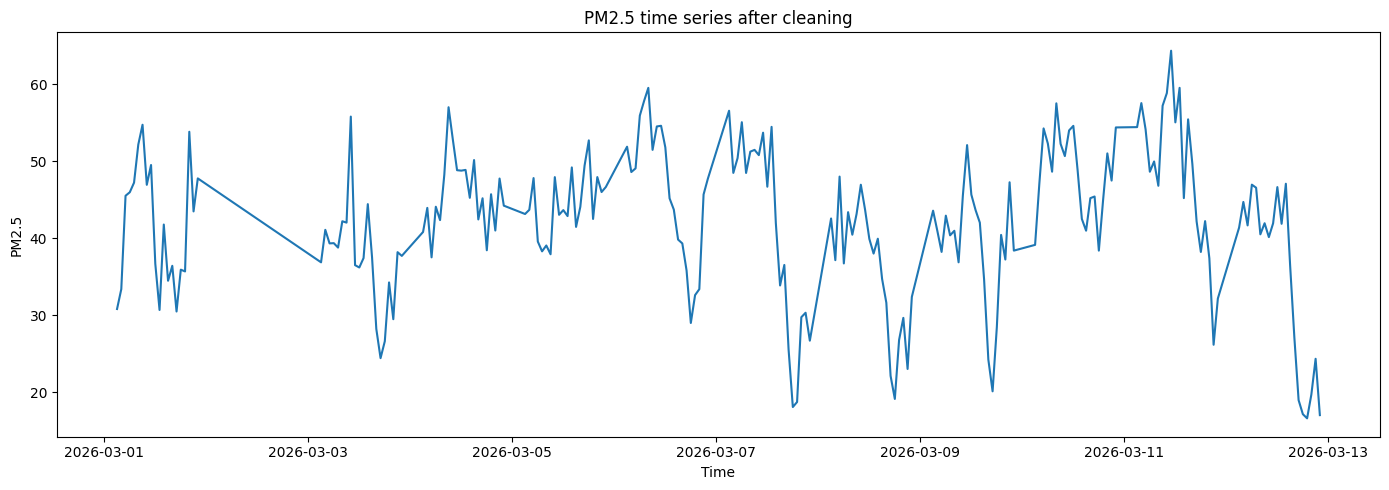

In [26]:
# Cell 20 — Plot PM2.5 time series after cleaning

plt.figure(figsize=(14, 5))
plt.plot(df["time"], df["PM25"])
plt.title("PM2.5 time series after cleaning")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_cleaning_pm25_timeseries.png", dpi=150)
plt.show()


In [27]:
# Cell 21 — Save cleaned dataset

df.to_csv(OUTPUT_FILE, index=False)

print("Cleaned dataset saved to:", OUTPUT_FILE)
print("Final shape:", df.shape)
print("Final missing values:", df.isna().sum().sum())


Cleaned dataset saved to: D:\eo\GeoProject_oo\data\processed\cleaned_dataset.csv
Final shape: (220, 41)
Final missing values: 0


In [28]:
# Cell 22 — Save cleaning report

report = pd.DataFrame({
    "column": df_raw.columns,
    "missing_count_before": df_raw.isna().sum().values,
    "missing_ratio_before_percent": (df_raw.isna().mean() * 100).values,
})

missing_after_for_report = df.isna().sum()
missing_after_ratio_for_report = df.isna().mean() * 100

report["missing_count_after"] = report["column"].map(missing_after_for_report).fillna("column_removed_or_transformed")
report["missing_ratio_after_percent"] = report["column"].map(missing_after_ratio_for_report).fillna("column_removed_or_transformed")

report.to_csv(REPORT_FILE, index=False)

print("Cleaning report saved to:", REPORT_FILE)
report


Cleaning report saved to: D:\eo\GeoProject_oo\data\processed\cleaning_report.csv


,column,missing_count_before,missing_ratio_before_percent,missing_count_after,missing_ratio_after_percent
0,time,0,0.000000,0.0,0.0
1,R_roi,0,0.000000,0.0,0.0
2,G_roi,0,0.000000,0.0,0.0
3,B_roi,0,0.000000,0.0,0.0
4,S_mean,0,0.000000,0.0,0.0
5,B_R_ratio,0,0.000000,0.0,0.0
6,contrast,0,0.000000,0.0,0.0
7,image_path,0,0.000000,column_removed_or_transformed,column_removed_or_transformed
8,PM25,0,0.000000,0.0,0.0
9,Unit,0,0.000000,column_removed_or_transformed,column_removed_or_transformed
